<a href="https://colab.research.google.com/github/juannhulk/test_project/blob/main/Assignment_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

df1 = pd.read_csv('2016_Entry_Exit.csv')
df2 = pd.read_csv('2017_Entry_Exit.csv')

df_gabungan = pd.concat([df1, df2], ignore_index=True)

In [23]:
print("Ukuran File 1:", df1.shape)
print("Ukuran File 2:", df2.shape)

print("Ukuran Gabungan:", df_gabungan.shape)

Ukuran File 1: (268, 11)
Ukuran File 2: (268, 11)
Ukuran Gabungan: (536, 11)


In [3]:
df_gabungan.head()

,nlc,Station,Borough,Note,Entry_Week,Entry_Saturday,Entry_Sunday,Exit_Week,Exit_Saturday,Exit_Sunday,AnnualEntryExit_Mill
0,500,Acton Town,Ealing,,9994,7082,4955,9581,6878,5151,6.27
1,501,Barbican,City of London,,21154,7092,4662,21000,7336,4794,11.97
2,502,Aldgate,City of London,,14212,4102,3058,13745,5728,4149,8.01
3,503,Aldgate East,Tower Hamlets,,21468,15292,13287,20132,13170,10947,13.43
4,505,Alperton,Brent,,4821,3453,2312,5188,3585,2376,3.17


In [24]:
df_gabungan.tail()

,nlc,Station,Borough,Note,Entry_Week,Entry_Saturday,Entry_Sunday,Exit_Week,Exit_Saturday,Exit_Sunday,AnnualEntryExit_Mill
531,768,Wimbledon Park,Merton,,3583,2648,1605,3301,2235,1600,262.95
532,770,Wood Green,Haringey,,20042,15815,11793,18949,16020,11415,1611.63
533,599,Wood Lane,Hammersmith and Fulham,,6242,4516,2267,6631,4294,2494,470.25
534,769,Woodford,Redbridge,,9442,6937,4140,9537,6301,4142,713.61
535,771,Woodside Park,Barnet,,5311,2997,2246,6089,3760,2967,411.16


In [25]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   nlc                   536 non-null    int64  
 1   Station               536 non-null    object 
 2   Borough               536 non-null    object 
 3   Note                  524 non-null    object 
 4   Entry_Week            536 non-null    int64  
 5   Entry_Saturday        536 non-null    int64  
 6   Entry_Sunday          536 non-null    int64  
 7   Exit_Week             536 non-null    int64  
 8   Exit_Saturday         536 non-null    int64  
 9   Exit_Sunday           536 non-null    int64  
 10  AnnualEntryExit_Mill  536 non-null    float64
dtypes: float64(1), int64(7), object(3)
memory usage: 46.2+ KB


--- Tabel Komparasi Geografis Berdasarkan Borough ---
                  Borough  Total_Volume_Juta  Rata_Rata_Juta  \
0     City of Westminster           81524.32     2629.816774   
1                  Camden           37726.79     2357.924375   
2          City of London           25505.13     2550.513000   
3                 Lambeth           23514.42     2939.302500   
4  Kensington and Chelsea           19181.83     1598.485833   
5               Southwark           17451.25     2493.035714   
6           Tower Hamlets           17372.27     1930.252222   
7               Islington           17306.29     1730.629000   
8  Hammersmith and Fulham           15116.35     1007.756667   
9                  Newham           14112.41     2352.068333   

   Nilai_Tengah_Juta  Jumlah_Stasiun  
0           1489.660              31  
1           1284.310              16  
2           1670.025              10  
3           1398.860               8  
4           1635.520              12  
5      

/tmp/ipykernel_14014/2203545077.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=borough_analysis.head(5), x='Total_Volume_Juta', y='Borough', palette='coolwarm')


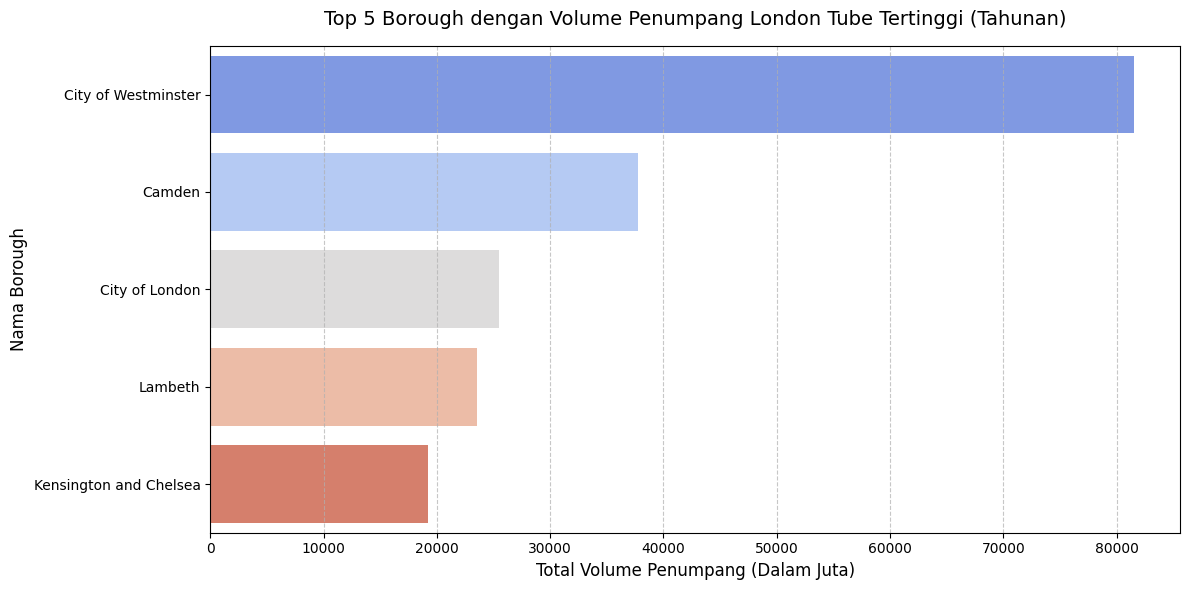

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_gabungan['Station'] = df_gabungan['Station'].str.strip()
df_stasiun_bersih = df_gabungan.groupby(['Station', 'Borough'])['AnnualEntryExit_Mill'].sum().reset_index()

borough_analysis = df_stasiun_bersih.groupby('Borough')['AnnualEntryExit_Mill'].agg(['sum', 'mean', 'median', 'count']).reset_index()
borough_analysis.columns = ['Borough', 'Total_Volume_Juta', 'Rata_Rata_Juta', 'Nilai_Tengah_Juta', 'Jumlah_Stasiun']
borough_analysis = borough_analysis.sort_values(by='Total_Volume_Juta', ascending=False).reset_index(drop=True)

print("--- Tabel Komparasi Geografis Berdasarkan Borough ---")
print(borough_analysis.head(10))



plt.figure(figsize=(12, 6))
sns.barplot(data=borough_analysis.head(5), x='Total_Volume_Juta', y='Borough', palette='coolwarm')

plt.title('Top 5 Borough dengan Volume Penumpang London Tube Tertinggi (Tahunan)', fontsize=14, pad=15)
plt.xlabel('Total Volume Penumpang (Dalam Juta)', fontsize=12)
plt.ylabel('Nama Borough', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
df_gabungan['Station'] = df_gabungan['Station'].str.strip()

df_stasiun_unik = df_gabungan.groupby(['Station', 'Borough'])[[
    'Entry_Week', 'Entry_Saturday', 'Entry_Sunday'
]].sum().reset_index() #DATA CLEANING WHITE SPACE

In [17]:
df_stasiun_unik = df_gabungan.groupby(['Station', 'Borough'])[[
    'Entry_Week', 'Entry_Saturday', 'Entry_Sunday'
]].sum().reset_index()

df_stasiun_unik['Total_Hari_Kerja'] = df_stasiun_unik['Entry_Week']
df_stasiun_unik['Total_Akhir_Pekan'] = df_stasiun_unik['Entry_Saturday'] + df_stasiun_unik['Entry_Sunday']
df_stasiun_unik['Rasio_Rekreasi'] = df_stasiun_unik['Total_Akhir_Pekan'] / df_stasiun_unik['Total_Hari_Kerja']


top_rekreasi_clean = df_stasiun_unik.sort_values(by='Rasio_Rekreasi', ascending=False).head(10)

top_komuter_clean = df_stasiun_unik.sort_values(by='Rasio_Rekreasi', ascending=True).head(10)
top_komuter_clean = top_komuter_clean.sort_values(by='Total_Hari_Kerja', ascending=False)


print("--- 10 STASIUN KOMUTER ---")
print(top_komuter_clean[['Station', 'Borough', 'Total_Hari_Kerja', 'Total_Akhir_Pekan', 'Rasio_Rekreasi']])

print("\n--- 10 STASIUN REKREASI  ---")
print(top_rekreasi_clean[['Station', 'Borough', 'Total_Hari_Kerja', 'Total_Akhir_Pekan', 'Rasio_Rekreasi']])

--- 10 STASIUN KOMUTER ---
              Station              Borough  Total_Hari_Kerja  \
11    Bank & Monument       City of London            230187   
149          Moorgate       City of London             95106   
78         Farringdon            Islington             68265   
42      Chancery Lane       City of London             64007   
210  St. James's Park  City of Westminster             52605   
38      Cannon Street       City of London             36613   
1             Aldgate       City of London             29292   
143     Mansion House       City of London             22880   
234  Upminster Bridge             Havering              4177   
45           Chigwell        Epping Forest              2116   

     Total_Akhir_Pekan  Rasio_Rekreasi  
11              101544        0.441137  
149              20447        0.214992  
78               23123        0.338724  
42               25212        0.393894  
210              27432        0.521471  
38               15535

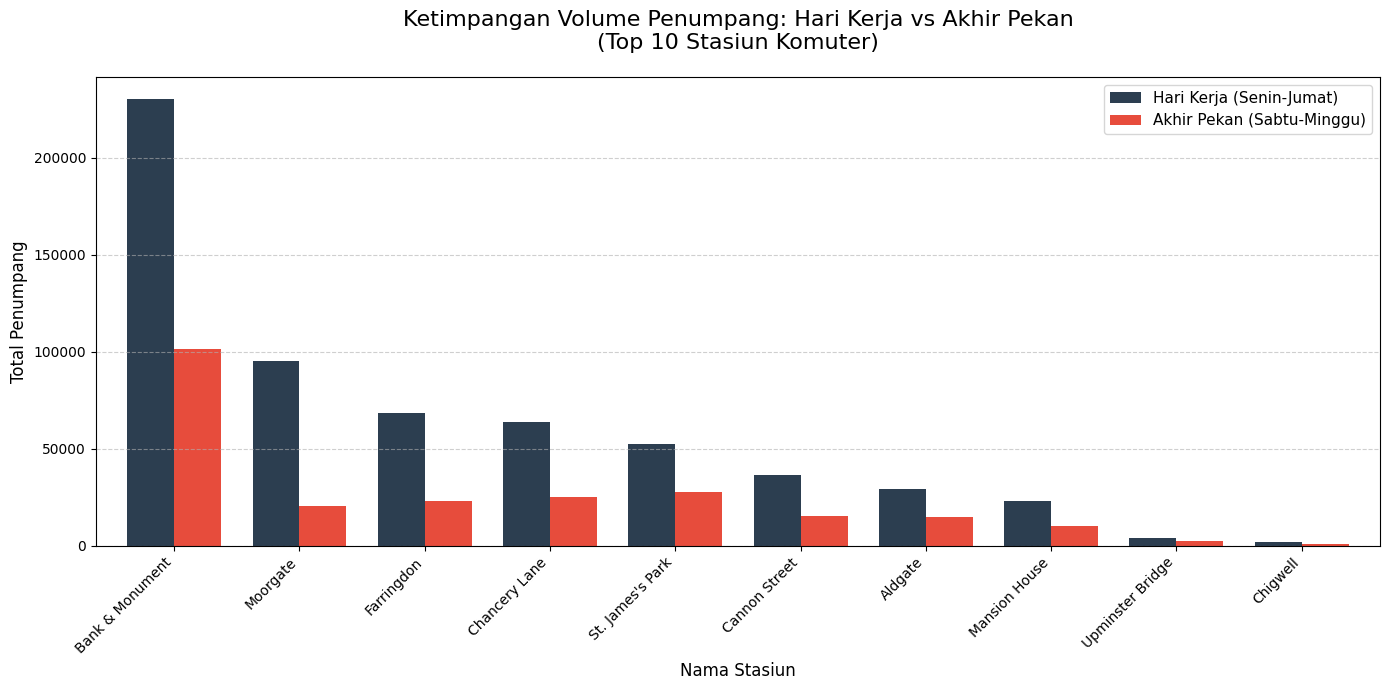

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot_komuter = top_komuter_clean.set_index('Station')[['Total_Hari_Kerja', 'Total_Akhir_Pekan']]

ax = df_plot_komuter.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#2c3e50', '#e74c3c'],
    width=0.75
)

plt.title('Ketimpangan Volume Penumpang: Hari Kerja vs Akhir Pekan\n(Top 10 Stasiun Komuter)', fontsize=16, pad=20)
plt.xlabel('Nama Stasiun', fontsize=12)
plt.ylabel('Total Penumpang', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.legend(['Hari Kerja (Senin-Jumat)', 'Akhir Pekan (Sabtu-Minggu)'], fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

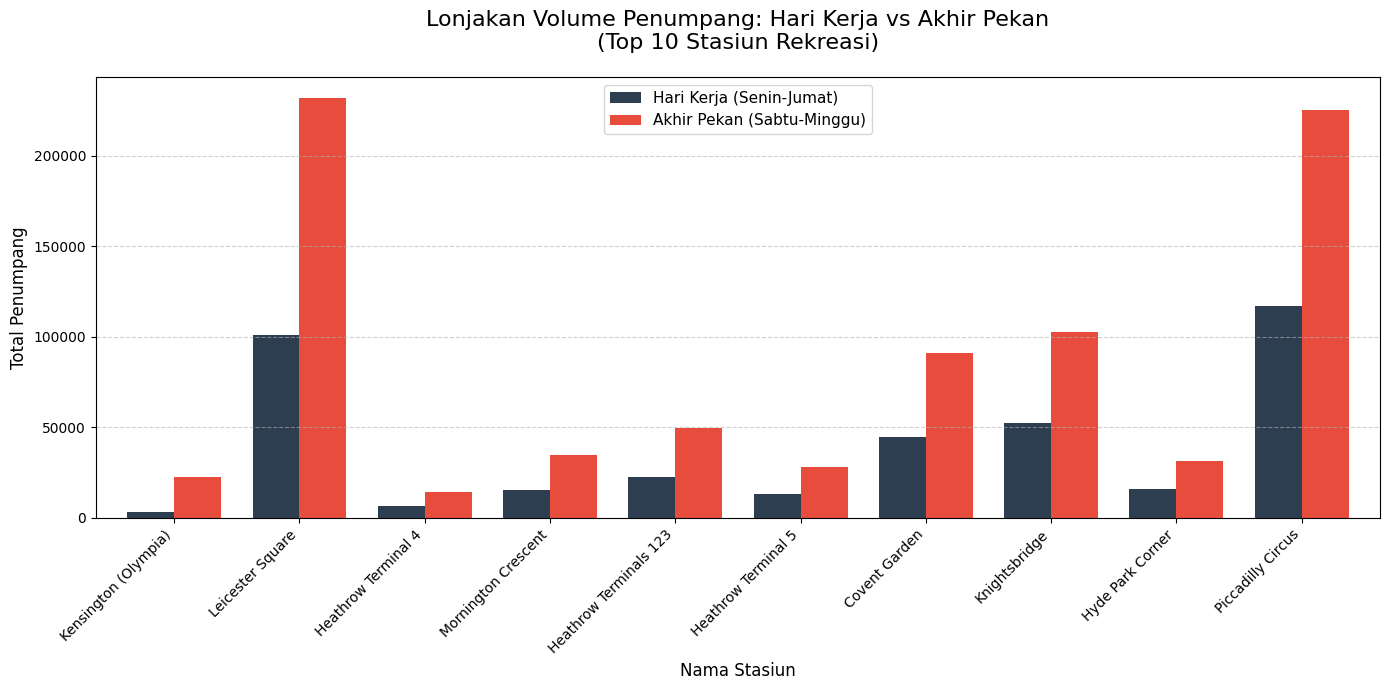

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot_rekreasi = top_rekreasi_clean.set_index('Station')[['Total_Hari_Kerja', 'Total_Akhir_Pekan']]

ax = df_plot_rekreasi.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#2c3e50', '#e74c3c'],
    width=0.75
)


plt.title('Lonjakan Volume Penumpang: Hari Kerja vs Akhir Pekan\n(Top 10 Stasiun Rekreasi)', fontsize=16, pad=20)
plt.xlabel('Nama Stasiun', fontsize=12)
plt.ylabel('Total Penumpang', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.legend(['Hari Kerja (Senin-Jumat)', 'Akhir Pekan (Sabtu-Minggu)'], fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)



plt.tight_layout()
plt.show()